In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier



from google.colab import files
import pandas as pd


uploaded = files.upload()


df = pd.read_csv("exams.csv")
print(df.head())


Saving exams.csv to exams (2).csv
   gender race/ethnicity parental level of education         lunch  \
0  female        group D                some college      standard   
1    male        group D          associate's degree      standard   
2  female        group D                some college  free/reduced   
3    male        group B                some college  free/reduced   
4  female        group D          associate's degree      standard   

  test preparation course  math score  reading score  writing score  
0               completed          59             70             78  
1                    none          96             93             87  
2                    none          57             76             77  
3                    none          70             70             63  
4                    none          83             85             86  


   gender  race/ethnicity  parental level of education  lunch  \
0       0               3                            4      1   
1       1               3                            0      1   
2       0               3                            4      0   
3       1               1                            4      0   
4       0               3                            0      1   

   test preparation course  math score  reading score  writing score  
0                        0          59             70             78  
1                        1          96             93             87  
2                        1          57             76             77  
3                        1          70             70             63  
4                        1          83             85             86  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------           

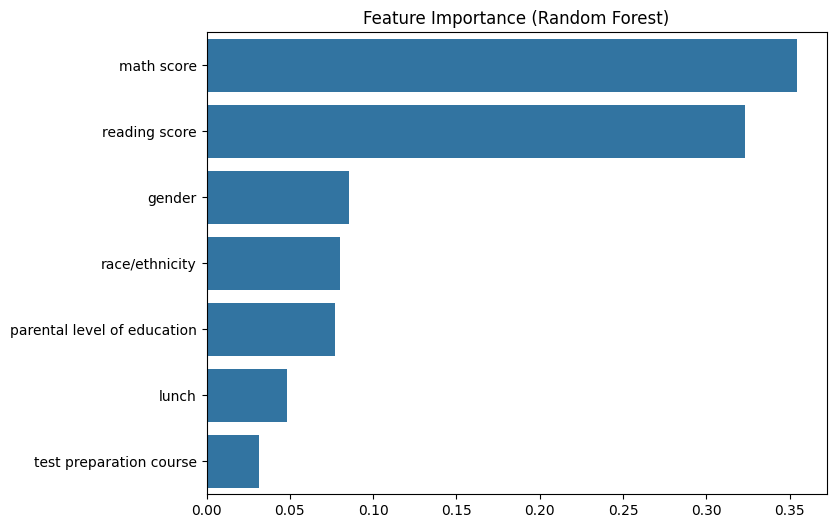

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:05:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.79
Confusion Matrix:
 [[84  0 14]
 [ 0 14  7]
 [14  7 60]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86        98
           1       0.67      0.67      0.67        21
           2       0.74      0.74      0.74        81

    accuracy                           0.79       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.79      0.79      0.79       200



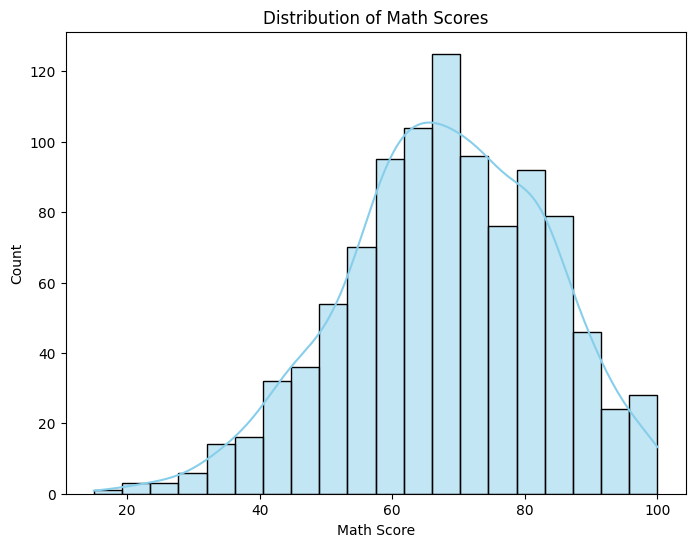

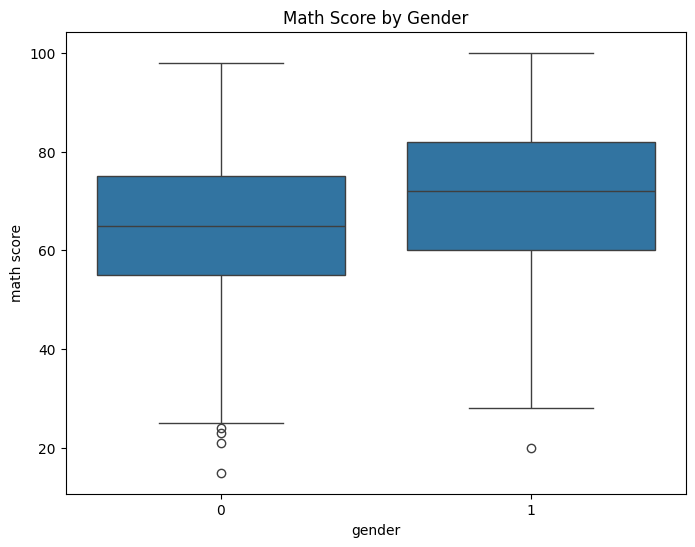

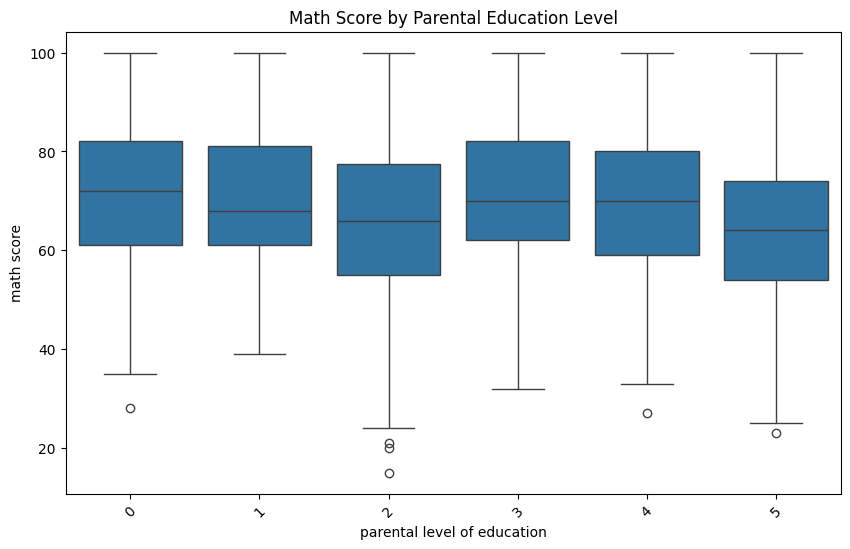

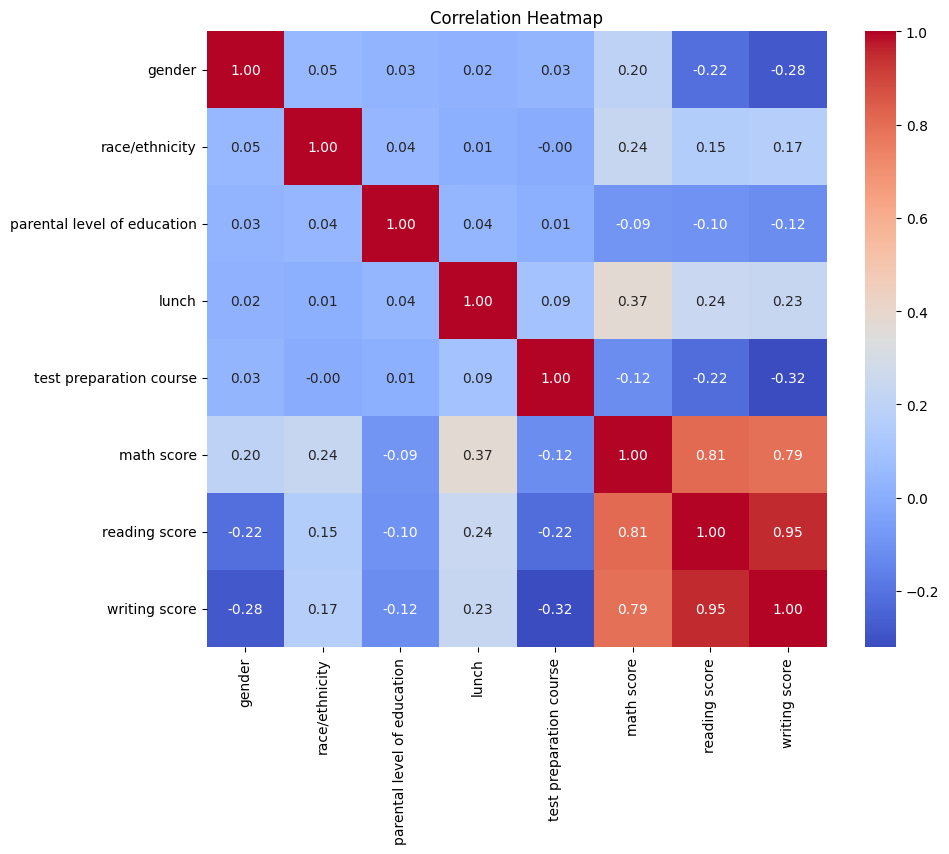

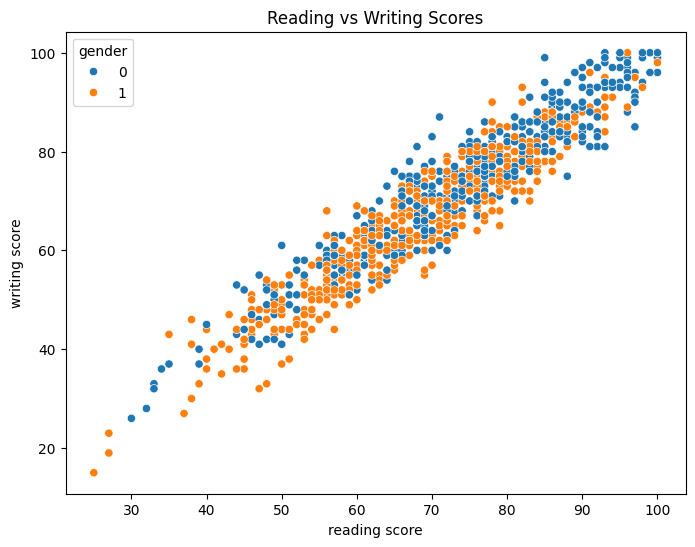

In [14]:

print(df.head())
print(df.info())
print(df.describe())


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])


X = df.drop("math score", axis=1)
y = pd.cut(df["math score"], bins=[0,50,70,100], labels=["Low","Medium","High"])


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8,6))
sns.barplot(x=importances[indices], y=[df.columns[i] for i in indices])
plt.title("Feature Importance (Random Forest)")
plt.show()



from sklearn.preprocessing import LabelEncoder
y_encoded = LabelEncoder().fit_transform(y)


X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)


from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train_enc)
y_pred_xgb = xgb.predict(X_test)


print("XGBoost Accuracy:", accuracy_score(y_test_enc, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test_enc, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test_enc, y_pred_xgb))


import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,6))
sns.histplot(df["math score"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(x="gender", y="math score", data=df)
plt.title("Math Score by Gender")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x="parental level of education", y="math score", data=df)
plt.xticks(rotation=45)
plt.title("Math Score by Parental Education Level")
plt.show()


plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


plt.figure(figsize=(8,6))
sns.scatterplot(x="reading score", y="writing score", data=df, hue="gender")
plt.title("Reading vs Writing Scores")
plt.show()


# Project Summary



THE project is a student performance prediction model built in Python using Google Colab. It analyzes exam scores (particularly math scores) and applies machine learning techniques to classify students into performance categories: Low, Medium, and High.

I have explored the dataset with pandas, numpy, seaborn, and matplotlib, performed preprocessing with LabelEncoder and StandardScaler, and trained multiple models:

Logistic Regression

Random Forest Classifier

XGBoost Classifier

I evaluated them using accuracy, confusion matrix, and classification reports, and visualized insights such as:

Distribution of math scores

Gender-based performance differences

Impact of parental education on scores

Correlation heatmaps and feature importance

# USE CASE


This project can be applied in educational analytics to:

Help schools identify students at risk of low performance.

Provide insights into factors influencing academic success (e.g., parental education, gender differences).

Support personalized learning strategies by predicting which students may need extra support.

Assist policymakers in designing targeted interventions for improving student outcomes.

# DATASET SOURCE

The dataset used is from Kaggle

#  THANK YOU FOR PAYING ATTENTION

PAYAL MISHRA